In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 


### Cleaning Columns for the Salary prediction

### 1. Salary column


In [3]:
df = pd.read_csv('tech_job_market_2019_2026.csv')

In [4]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [6]:
df['salary_min_usd'].isnull().sum()

np.int64(3318)

In [7]:
df['salary_max_usd'].isnull().sum()

np.int64(3318)

In [8]:
df['salary_min_usd'] = df['salary_min_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [9]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')


In [10]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].mean()).astype(int)

In [11]:
df['salary_min_usd']

0             -1
1         114677
2         238800
3          96300
4         186800
           ...  
114995    215300
114996     87500
114997    126000
114998    156000
114999    120400
Name: salary_min_usd, Length: 115000, dtype: int64

In [12]:
df['salary_max_usd'] = df['salary_max_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [13]:
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'],errors='coerce')

In [14]:
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].mean())

In [15]:
df['salary_max_usd'].astype(int)

0             -1
1         141712
2         274700
3         104000
4         245400
           ...  
114995    254300
114996    113500
114997    156400
114998    174100
114999    147000
Name: salary_max_usd, Length: 115000, dtype: int64

In [16]:
df.loc[df['salary_min_usd'] <= 0, 'salary_min_usd'] = np.nan
df.loc[df['salary_max_usd'] <= 0, 'salary_max_usd'] = np.nan

In [17]:
df['Average_Salary'] = np.where(
    df['salary_min_usd'] > df['salary_max_usd'],
    None,
    (df['salary_max_usd'] + df['salary_min_usd']) / 2
)

In [18]:
df['Average_Salary']

0                  NaN
1         128194.58699
2             256750.0
3             100150.0
4             216100.0
              ...     
114995        234800.0
114996        100500.0
114997        141200.0
114998        165050.0
114999        133700.0
Name: Average_Salary, Length: 115000, dtype: object

In [19]:
df['Average_Salary'].isna().sum()

np.int64(1189)

In [20]:
df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\2889260269.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


In [21]:
df['Average_Salary'].astype(int)

0         129035
1         128194
2         256750
3         100150
4         216100
           ...  
114995    234800
114996    100500
114997    141200
114998    165050
114999    133700
Name: Average_Salary, Length: 115000, dtype: int64

In [22]:
df['Average_experience'] = (df['years_experience_min']+df['years_experience_max'])/2

In [23]:
df['Average_experience']

0          4.0
1          2.5
2         11.0
3          2.5
4          7.5
          ... 
114995    11.5
114996     7.0
114997     4.0
114998     6.5
114999     4.5
Name: Average_experience, Length: 115000, dtype: float64

In [24]:
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna(df['number_of_interview_rounds'].median())

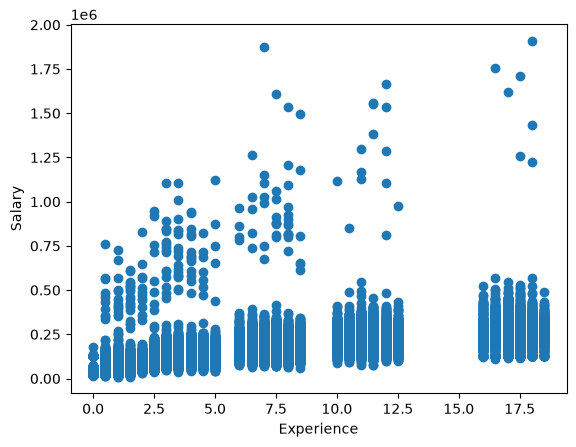

In [25]:
plt.scatter(y=df['Average_Salary'],x=df['Average_experience'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

### Using Categorical columns 
1. work_mode
2. job_role
3. job_location 
4. sectornum 
5. seniority_level

Cleaning work_mode

In [26]:
df['work_mode'].value_counts()

work_mode
Hybrid            48946
Remote            32320
Onsite            26731
HYBRID             1511
hybrid             1348
remote              598
Work From Home      567
WFH                 557
REMOTE              556
ONSITE              474
onsite              468
In-office           466
On-site             458
Name: count, dtype: int64

In [27]:
df['work_mode'].unique()

array(['Hybrid', 'Remote', 'Onsite', 'HYBRID', 'In-office', 'hybrid',
       'remote', 'WFH', 'onsite', 'REMOTE', 'ONSITE', 'On-site',
       'Work From Home'], dtype=object)

In [28]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

In [29]:
changed_work_mode = {
    'hybrid':'Hybrid',
    'remote':'Remote','wfh':'Remote','work from home':'Remote',
    'ONSITE':'Onsite','onsite':'Onsite','on-site':'Onsite','in-office':'Onsite','Onsite':'Onsite'
    }

In [30]:
df['work_mode'] = df['work_mode'].map(changed_work_mode)

In [31]:
df['work_mode'].value_counts()

work_mode
Hybrid    51805
Remote    34598
Onsite    28597
Name: count, dtype: int64

In [32]:
df['work_mode'].isna().sum()

np.int64(0)

In [33]:
df['job_location_country'].value_counts()

job_location_country
USA            36269
India          19639
UK             14620
Germany         7178
Canada          6319
Singapore       5781
Brazil          5360
France          4814
Australia       3585
Israel          3292
UAE             3059
Netherlands     2937
Ireland         2147
Name: count, dtype: int64

In [34]:
df['job_role'].isna().sum()
df['job_role'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 115000 entries, 0 to 114999
Series name: job_role
Non-Null Count   Dtype 
--------------   ----- 
115000 non-null  object
dtypes: object(1)
memory usage: 898.6+ KB


In [35]:
df['seniority_level'].value_counts()
df['seniority_level'].isna().sum()

np.int64(0)

Cleaning Sector

In [36]:
df['sector'].value_counts()

sector
E-commerce       16680
HealthTech       15273
Fintech          13134
EdTech           11523
Social/AdTech     9022
AI/ML             8900
SaaS              8620
Crypto/Web3       8038
Cloud/Infra       6567
Cybersecurity     5739
Logistics         5289
Gaming            5045
e-commerce         175
healthtech         147
fintech            141
edtech             126
social/adtech      100
crypto/web3         89
ai/ml               88
saas                88
cloud/infra         60
gaming              57
cybersecurity       50
logistics           49
Name: count, dtype: int64

In [37]:
df['sector'] = df['sector'].str.strip().str.lower()

In [38]:
cleaned_sector = {
    "e-commerce":"E-commerce",
    "healthtech":"HealthTech",
    "fintech":"Fintech",
    "edtech":"EdTech",
    "social/adtech":"Social/AdTech",
    "ai/ml":"AI/ML",
    "saas":"SaaS",
    "crypto/web3":"Crypto/Web3",
    "cloud/infra":"Cloud/Infra",
    "cybersecurity":"Cybersecurity",
    "logistics":"Logistics",
    "gaming":"Gaming"
}

In [39]:
df['sector'] = df['sector'].map(cleaned_sector)

In [40]:
df['sector'].value_counts()

sector
E-commerce       16855
HealthTech       15420
Fintech          13275
EdTech           11649
Social/AdTech     9122
AI/ML             8988
SaaS              8708
Crypto/Web3       8127
Cloud/Infra       6627
Cybersecurity     5789
Logistics         5338
Gaming            5102
Name: count, dtype: int64

In [41]:
df['sector'].isna().sum()

np.int64(0)

In [42]:
features = [
    'job_role',
    'seniority_level',
    'sector',
    'job_location_country',
    'work_mode',
    'Average_experience',
    'number_of_interview_rounds'
]

model_df = df[features + ['Average_Salary']].copy()
print(model_df.shape)
model_df.head()

(115000, 8)


,job_role,seniority_level,sector,job_location_country,work_mode,Average_experience,number_of_interview_rounds,Average_Salary
0,SOC Analyst,Mid,HealthTech,Germany,Hybrid,4.0,4.0,129035.254556
1,Mobile Engineer (iOS),Mid,Cloud/Infra,USA,Remote,2.5,2.0,128194.586990
2,QA Engineer,Lead,HealthTech,USA,Hybrid,11.0,4.0,256750.000000
3,Research Scientist,Entry,HealthTech,Germany,Onsite,2.5,1.0,100150.000000
4,Product Manager,Senior,Social/AdTech,India,Hybrid,7.5,3.0,216100.000000


In [43]:
model_df.isna().sum()

job_role                      0
seniority_level               0
sector                        0
job_location_country          0
work_mode                     0
Average_experience            0
number_of_interview_rounds    0
Average_Salary                0
dtype: int64

## Graph ploting for Visualization

### 1. To check salary distributioin

<Axes: ylabel='Average_Salary'>

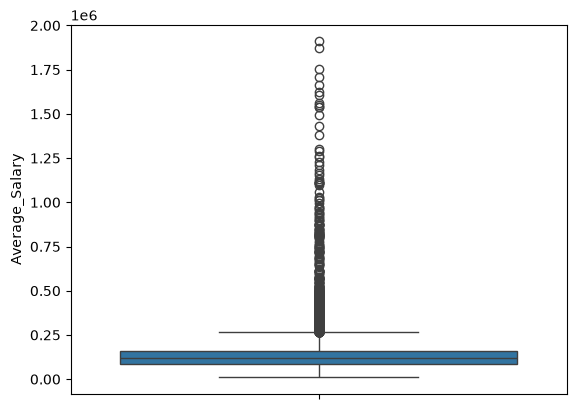

In [44]:
sns.boxplot(df['Average_Salary'])

**Insight** : There are a lot of outliers in the salary. 

Average salary vs Number of interview_rounds

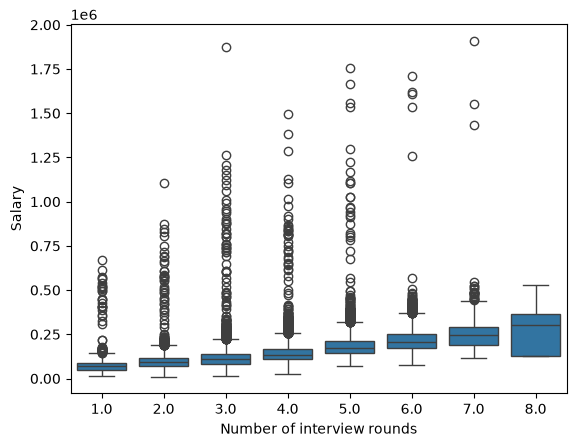

In [45]:
sns.boxplot(y= df['Average_Salary'],x= df['number_of_interview_rounds'])
plt.xlabel('Number of interview rounds')
plt.ylabel('Salary')
plt.show()

**Insight** : As the number of interview rounds are increasing, median salary is also increasing 

Salary vs Experience graph

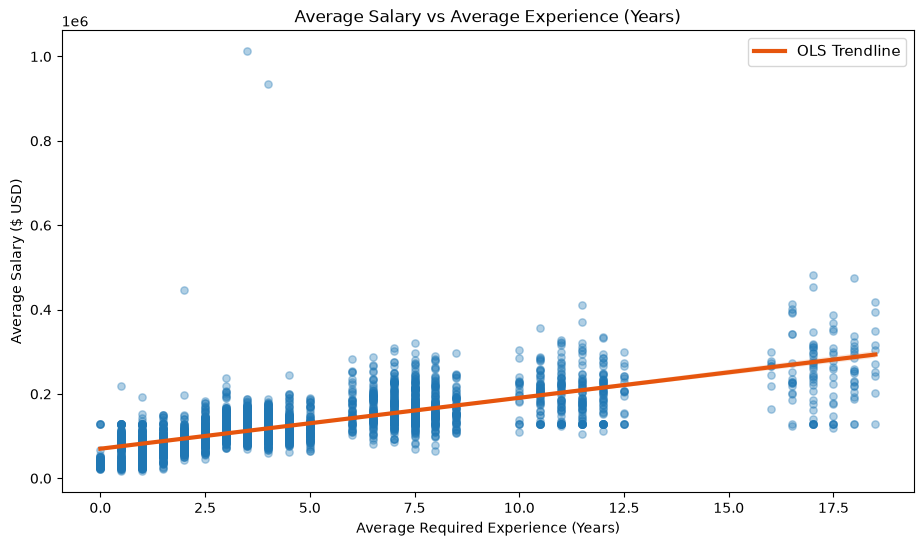

In [46]:
plt.figure(figsize=(11, 6))

sample_df = model_df.sample(n=3000, random_state=42)

sns.regplot(
    data=sample_df,
    x='Average_experience',
    y='Average_Salary',
    scatter_kws={'alpha': 0.35, 'color': '#1f77b4', 's': 28},
    line_kws={'color': '#e6550d', 'linewidth': 3, 'label': 'OLS Trendline'}
)

plt.title('Average Salary vs Average Experience (Years)')
plt.xlabel('Average Required Experience (Years)')
plt.ylabel('Average Salary ($ USD)')
plt.legend(fontsize=11)

plt.show()

Salary across seniority_level

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\1653539820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


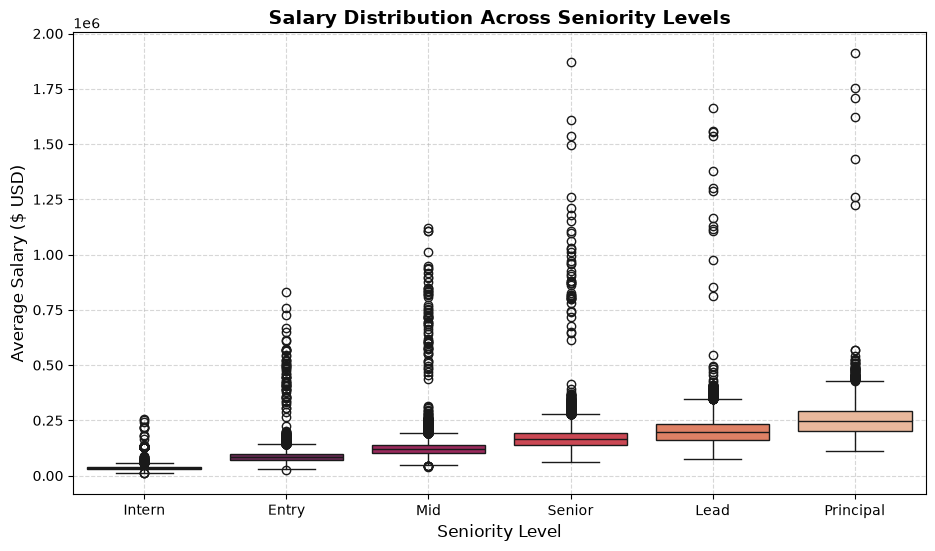

Mean Salary by Seniority Level:
seniority_level
Intern        38247.58
Entry         86809.36
Mid          122729.27
Senior       171072.34
Lead         203132.03
Principal    250172.12
Name: Average_Salary, dtype: float64


In [47]:

seniority_order = ['Intern', 'Entry', 'Mid', 'Senior', 'Lead', 'Principal']

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=model_df,
    x='seniority_level',
    y='Average_Salary',
    order=seniority_order,
    palette='rocket'
)
plt.title('Salary Distribution Across Seniority Levels', fontsize=14, fontweight='bold')
plt.xlabel('Seniority Level', fontsize=12)
plt.ylabel('Average Salary ($ USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Mean Salary by Seniority Level:")
print(model_df.groupby('seniority_level')['Average_Salary'].mean().reindex(seniority_order).round(2))

**Insight** : the increasing mean value across the seniority level shows a strong relation of seniority level with salary. this means seniority level will have high weightage in the perdiction

Salary vs job location 

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\1712208234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


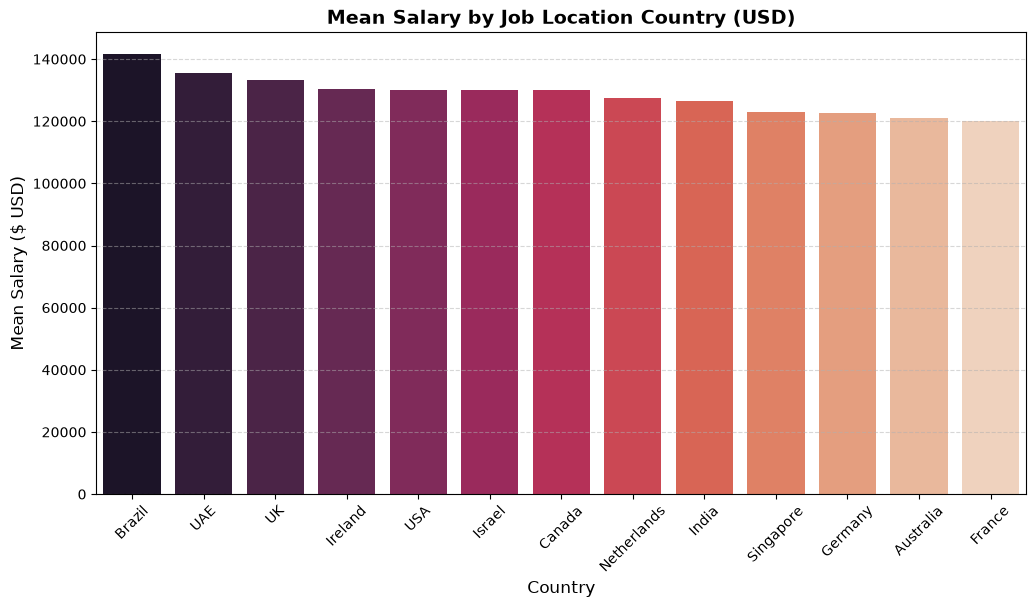

In [48]:

location_order = model_df.groupby('job_location_country')['Average_Salary'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(
    data=model_df,
    x='job_location_country',
    y='Average_Salary',
    order=location_order,
    palette='rocket',
    errorbar=None
)
plt.title('Mean Salary by Job Location Country (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Mean Salary ($ USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight** : salary also depends on the country. 

Salary across work mode

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\3321667380.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


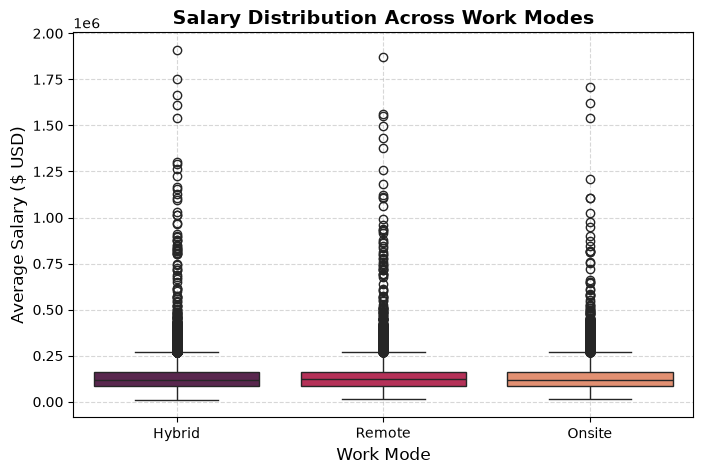

Mean Salary by Work Mode:
work_mode
Hybrid    128879.50
Onsite    129042.07
Remote    129262.85
Name: Average_Salary, dtype: float64


In [49]:

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=model_df,
    x='work_mode',
    y='Average_Salary',
    palette='rocket',
    ax=ax
)
ax.set_title('Salary Distribution Across Work Modes', fontsize=14, fontweight='bold')
ax.set_xlabel('Work Mode', fontsize=12)
ax.set_ylabel('Average Salary ($ USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Mean Salary by Work Mode:")
print(model_df.groupby('work_mode')['Average_Salary'].mean().round(2))

**Insight** : Salary doesn't depend on the work mode that much

Salary dependency on job_role

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\3623003707.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


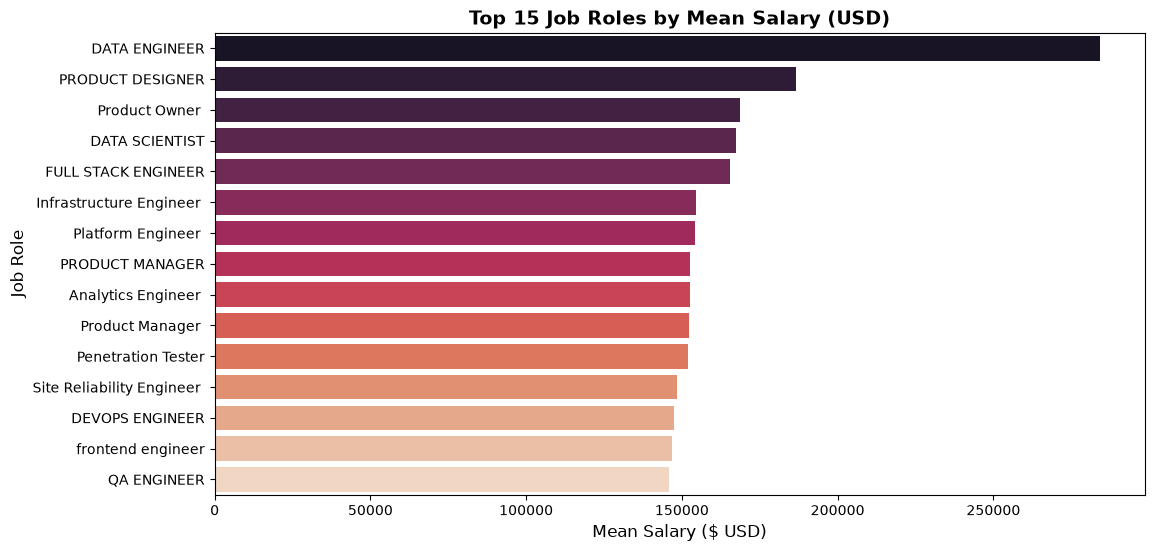

In [50]:

top_roles = model_df.groupby('job_role')['Average_Salary'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index,
    palette='rocket'
)
plt.title('Top 15 Job Roles by Mean Salary (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Salary ($ USD)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.show()

**Insight** : Salary defers on the job role. 

Salary across job role

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\1026818235.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


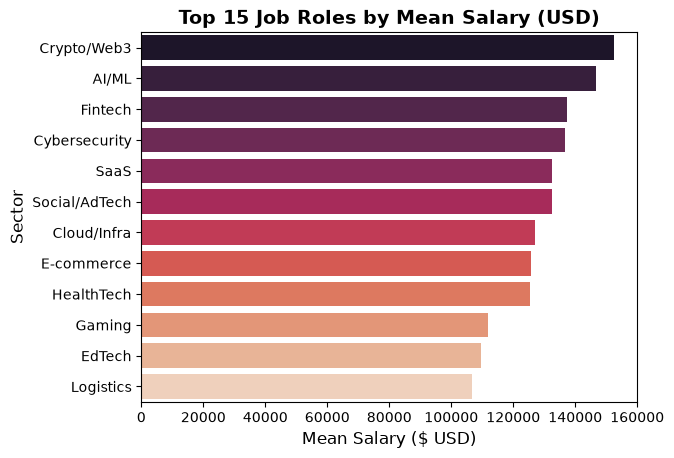

In [51]:

top_roles = model_df.groupby('sector')['Average_Salary'].mean().sort_values(ascending=False)


sns.barplot(
    x=top_roles.values,
    y=top_roles.index,
    palette='rocket'
)
plt.title('Top 15 Job Roles by Mean Salary (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Salary ($ USD)', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.show()

**Insight** : Salary also depend on the job role 

## Model training

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [53]:
x = model_df[['job_role','seniority_level','sector','job_location_country','work_mode','Average_experience','number_of_interview_rounds']]
y = model_df['Average_Salary']

x_encoded = pd.get_dummies(x,drop_first=True)
print(x_encoded.shape)

x_train, x_test, y_train, y_test = train_test_split(x_encoded,y,test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(x_train,y_train)

(115000, 191)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Testing

In [54]:
y_pred = lr.predict(x_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [55]:
print("=" * 55)
print("           LINEAR REGRESSION TEST EVALUATION")
print("=" * 55)
print(f"Mean Absolute Error (MAE):       ${mae:,.2f}")
print(f"Mean Squared Error (MSE):        {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")
print(f"R² Score (Variance Explained):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 55)

           LINEAR REGRESSION TEST EVALUATION
Mean Absolute Error (MAE):       $24,557.96
Mean Squared Error (MSE):        1,831,950,560.61
Root Mean Squared Error (RMSE):  $42,801.29
R² Score (Variance Explained):   0.5963 (59.63%)


## Actual Vs Predicted Salary

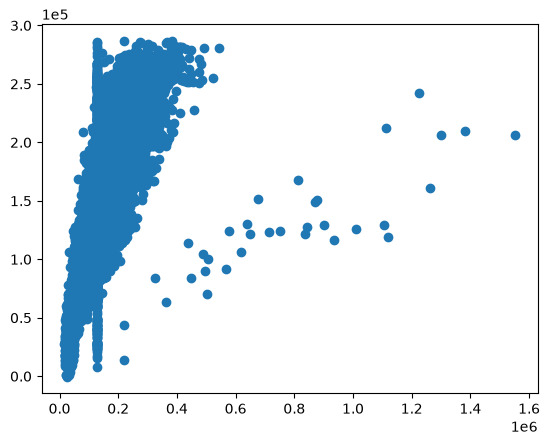

In [56]:
plt.scatter(y_test,y_pred)
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.show()

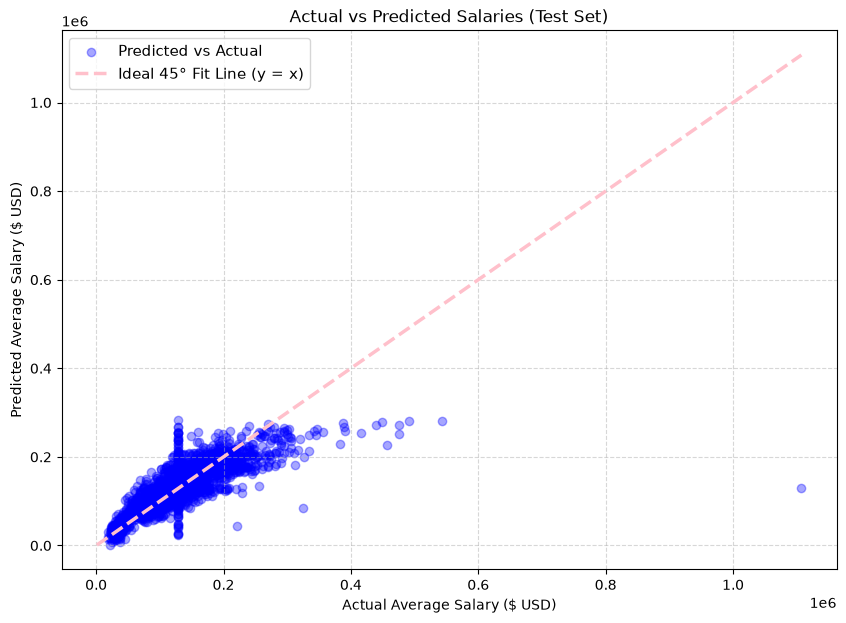

In [57]:

plt.figure(figsize=(10, 7))

# Sample 2,500 test points for clean rendering
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=min(2500, len(y_test)), replace=False)
y_test_sub = y_test.iloc[sample_idx]
y_pred_sub = y_pred[sample_idx]

plt.scatter(
    y_test_sub, 
    y_pred_sub, 
    alpha=0.35, 
    color='blue',
    label='Predicted vs Actual'
)


min_val = min(y_test_sub.min(), y_pred_sub.min())
max_val = max(y_test_sub.max(), y_pred_sub.max())
plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='pink', 
    linestyle='--', 
    linewidth=2.5, 
    label='Ideal 45° Fit Line (y = x)'
)

plt.title('Actual vs Predicted Salaries (Test Set)')
plt.xlabel('Actual Average Salary ($ USD)')
plt.ylabel('Predicted Average Salary ($ USD)')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Part 2 
Layoff prediction


### Columns Used as Input
    posting_year
	company_type
	sector (already cleaned)
	seniority_level (already cleaned)
	work mode (already cleaned)
	job_location_country (already cleaned)
	Average_experience (already cleaned)
	number_of_interview_rounds (already cleaned)

### Column Used as Output
    layoff_within_12_months_flag



## Cleaning columns

posting_year, company_type, company_size_employee, layoff_within_12_months_flag

In [58]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
N        25170
False    24999
0        24976
No       24780
Y         3818
Yes       3801
1         3764
True      3692
Name: count, dtype: int64

In [59]:
df['layoff_within_12_months_flag'].isna().sum()

np.int64(0)

In [60]:
df['layoff'] = df['layoff_within_12_months_flag'].replace({'N':0,'False':0,'0':0,'No':0,
'Y':1,'Yes':1,'1':1,'True':1})

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\820169534.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['layoff'] = df['layoff_within_12_months_flag'].replace({'N':0,'False':0,'0':0,'No':0,


In [61]:
df['layoff'].isna().sum()

np.int64(0)

In [62]:
df['layoff'].dtype

dtype('int64')

- All the values in layoff converted into 0 and 1

In [63]:
df['posting_date']

0         2023-09-21
1         2025-05-11
2         2025-12-01
3         2020-11-21
4         2025-07-03
             ...    
114995    2025-10-25
114996    2025-01-20
114997    2024-01-06
114998    2024-07-24
114999    2020-12-08
Name: posting_date, Length: 115000, dtype: object

In [64]:
df['posting_year'] = pd.to_datetime(df['posting_date']).dt.year

In [65]:
df['posting_year']

0         2023
1         2025
2         2025
3         2020
4         2025
          ... 
114995    2025
114996    2025
114997    2024
114998    2024
114999    2020
Name: posting_year, Length: 115000, dtype: int32

In [66]:
df['posting_year'].isna().sum()

np.int64(0)

In [67]:
df['company_type']

0                MNC
1           Mid-size
2                MNC
3            Unicorn
4                MNC
             ...    
114995    FAANG-tier
114996           MNC
114997       Startup
114998      Mid-size
114999           MNC
Name: company_type, Length: 115000, dtype: object

In [68]:
df['company_type'].value_counts()

company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64

In [69]:
df['company_type'].isna().sum()

np.int64(0)

- Now all the required columns cleaned and ready for EDA

#### creating new data frame for Part 2 

In [70]:
fcuk = ['posting_year',
	'company_type',
	'sector',
	'seniority_level',
	'work_mode' ,
	'job_location_country',
	'Average_experience',
	'number_of_interview_rounds']
model2_df = df[fcuk + ['layoff']].copy()

In [71]:
model2_df.shape

(115000, 9)

In [72]:
model2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   posting_year                115000 non-null  int32  
 1   company_type                115000 non-null  object 
 2   sector                      115000 non-null  object 
 3   seniority_level             115000 non-null  object 
 4   work_mode                   115000 non-null  object 
 5   job_location_country        115000 non-null  object 
 6   Average_experience          115000 non-null  float64
 7   number_of_interview_rounds  115000 non-null  float64
 8   layoff                      115000 non-null  int64  
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 7.5+ MB


## Exploratory Data Analysis (EDA)

C:\Users\anshu\AppData\Local\Temp\ipykernel_26200\1479958355.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=model2_df, x="layoff",palette='rocket')


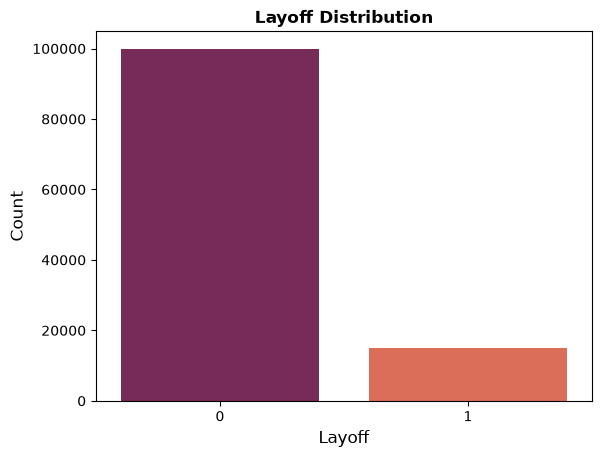

In [73]:
sns.countplot(data=model2_df, x="layoff",palette='rocket')
plt.title("Layoff Distribution",fontsize=12,fontweight='bold')
plt.xlabel("Layoff",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

In [74]:
model2_df['layoff'].value_counts()

layoff
0    99925
1    15075
Name: count, dtype: int64

In [75]:
x1 = model2_df[['posting_year','company_type','sector','seniority_level','work_mode','job_location_country','Average_experience','number_of_interview_rounds']]

In [76]:
y1 = model2_df['layoff']

In [77]:
model2_df.head(
    
)

,posting_year,company_type,sector,seniority_level,work_mode,job_location_country,Average_experience,number_of_interview_rounds,layoff
0,2023,MNC,HealthTech,Mid,Hybrid,Germany,4.0,4.0,0
1,2025,Mid-size,Cloud/Infra,Mid,Remote,USA,2.5,2.0,0
2,2025,MNC,HealthTech,Lead,Hybrid,USA,11.0,4.0,0
3,2020,Unicorn,HealthTech,Entry,Onsite,Germany,2.5,1.0,1
4,2025,MNC,Social/AdTech,Senior,Hybrid,India,7.5,3.0,1


#### Encoding Features

##### Categorical columns are 
	company_type (Categorical and use one-hot encoding)
	sector (Categorical and use one-hot encoding)
	seniority_level (Categorical and use label encoding)
	work mode (Categorical and use one-hot encoding)
	job_location_country (Categorical and use one-hot encoding)

In [78]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [79]:
encoder1 = OneHotEncoder(sparse_output=False)
encoder2 = LabelEncoder()
encoded = encoder2.fit_transform(model2_df['seniority_level'])
encoded2 = encoder1.fit_transform(model2_df[['company_type','sector','work_mode','job_location_country']])
encoded1_df = pd.DataFrame(encoded,columns=['seniority_level'])
encoded2_df = pd.DataFrame(encoded2,columns=encoder1.get_feature_names_out(['company_type','sector','work_mode','job_location_country']))

In [80]:
encoded_df = pd.concat([encoded1_df,encoded2_df,model2_df['layoff']],axis=1)

In [81]:
encoded_df

,seniority_level,company_type_FAANG-tier,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,sector_AI/ML,sector_Cloud/Infra,sector_Crypto/Web3,sector_Cybersecurity,...,job_location_country_Germany,job_location_country_India,job_location_country_Ireland,job_location_country_Israel,job_location_country_Netherlands,job_location_country_Singapore,job_location_country_UAE,job_location_country_UK,job_location_country_USA,layoff
0,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114995,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
114996,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
114997,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
114998,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [82]:
encoded_df.shape

(115000, 35)

In [83]:
encoded_df.head()

,seniority_level,company_type_FAANG-tier,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,sector_AI/ML,sector_Cloud/Infra,sector_Crypto/Web3,sector_Cybersecurity,...,job_location_country_Germany,job_location_country_India,job_location_country_Ireland,job_location_country_Israel,job_location_country_Netherlands,job_location_country_Singapore,job_location_country_UAE,job_location_country_UK,job_location_country_USA,layoff
0,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [84]:
parameter={
    'criterion':['gini', 'entropy', 'log_loss'],
    'splitter':['best', 'random' ],
    'max_depth' : [1,2,3,4,5],
    'max_features':['auto', 'sqrt', 'log2']
}

### Spliting Data

In [85]:
X = encoded_df.iloc[:,:-1]
Y = encoded_df['layoff']

In [86]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [87]:
pd.Series(Y_test).value_counts()

layoff
0    19985
1     3015
Name: count, dtype: int64

In [88]:
ss = StandardScaler()

In [89]:
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)


### Training Model using Decision Tree Classifier

In [90]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay

In [91]:
dt = DecisionTreeClassifier()

In [92]:
dt.fit(X_train_scaled,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Splitting criterion
Decision tree decide the spliting on the basis of gini impurity G.I = 1 - sigma of(p^2) where sigma ranges from 1 to n.
Decision tree selects the best feature for the split using information gain which uses entropy to get the value.
entropy formula is : H(s) = -pplog(pp)-pnlog(pn) where pp is the probability of positive(1) and pn is the probability of negative(0).

In [93]:
Y_pred = dt.predict(X_test_scaled)

In [147]:
acc = accuracy_score(Y_pred,Y_test)
pre = precision_score(Y_pred,Y_test)
recall = recall_score(Y_pred,Y_test)
f1 = f1_score(Y_pred,Y_test)
con = confusion_matrix(Y_pred,Y_test)

In [148]:
print(round(acc,2))
print(round(pre,2))
print(round(recall,2))
print(round(f1,2))
print(con)

0.87
0.01
0.17
0.01
[[19875  2992]
 [  110    23]]


In [108]:
d = ConfusionMatrixDisplay(confusion_matrix=con)

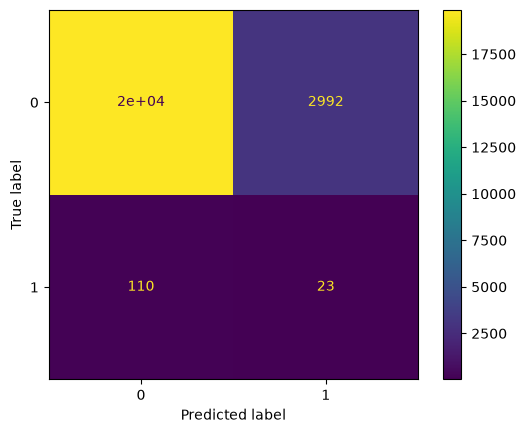

In [109]:
d.plot()

### Training Model Using Logistic Regression

In [96]:
lg = LogisticRegression(class_weight='balanced')

In [97]:
lg.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
lg_Y_pred = lg.predict(X_test_scaled)

In [138]:
lg_acc = accuracy_score(Y_test,lg_Y_pred)
lg_pre = precision_score(Y_test,lg_Y_pred)
lg_recall = recall_score(Y_test,lg_Y_pred)
lg_f1 = f1_score(Y_test,lg_Y_pred)
lg_con = confusion_matrix(Y_test,lg_Y_pred)

In [139]:
print(round(lg_acc,2))
print(round(lg_pre,2))
print(round(lg_recall,2))
print(round(lg_f1,2))
print(lg_con)

0.6
0.17
0.52
0.25
[[12290  7695]
 [ 1462  1553]]


**Insight** : Confusion matrix showing that my model is not predicting for True values in it. This is a example of classification problem

In [101]:
pd.Series(Y_test).value_counts()

layoff
0    19985
1     3015
Name: count, dtype: int64

In [102]:
print(pd.Series(lg_Y_pred).value_counts())

0    13752
1     9248
Name: count, dtype: int64


In [111]:
lg_d = ConfusionMatrixDisplay(confusion_matrix=lg_con)

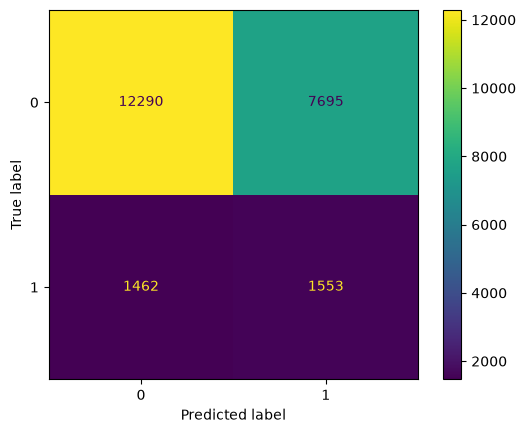

In [113]:
lg_d.plot()

### Training Model using SVC

In [168]:
svc = SVC(kernel='rbf',class_weight='balanced')
svc.fit(X_train_scaled,Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [170]:
SV_rbf_Y_pred = svc.predict(X_test.iloc[:200,:])

c:\Users\anshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [188]:
Y_test_new = Y_test.iloc[:200]

In [189]:
sv_rbf_acc = accuracy_score(Y_test_new,SV_rbf_Y_pred)
sv_rbf_pre = precision_score(Y_test_new,SV_rbf_Y_pred)
sv_rbf_recall = recall_score(Y_test_new,SV_rbf_Y_pred)
sv_rbf_f1 = f1_score(Y_test_new,SV_rbf_Y_pred)

In [ ]:
svc_linear = SVC(kernel='linear',class_weight='balanced')
                                                        


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [191]:
sv_linear_Y_pred = svc_linear.predict(X_test.iloc[:200,:])

c:\Users\anshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [192]:
sv_linear_acc = accuracy_score(Y_test[:200],sv_linear_Y_pred)
sv_linear_pre = precision_score(Y_test[:200],sv_linear_Y_pred)
sv_linear_recall = recall_score(Y_test[:200],sv_linear_Y_pred)
sv_linear_f1 = f1_score(Y_test[:200],sv_linear_Y_pred)

## Part D

In [193]:
print("\t\t\tAccuracy\tPrecision\tRecall\tF1-Score")
print(f"Decision Tree\t\t{round(acc,2)}\t\t{round(pre,2)}\t\t{round(recall,2)}\t{round(f1,2)}")
print(f"Logistic Regression\t{round(lg_acc,2)}\t\t{round(lg_pre,2)}\t\t{round(lg_recall,2)}\t{round(lg_f1,2)}")
print(f"SVC (RBF)\t\t{round(sv_rbf_acc,2)}\t\t{round(sv_rbf_pre,2)}\t\t{round(sv_rbf_recall,2)}\t{round(sv_rbf_f1,2)}")
print(f"SVC (Linear)\t\t{round(sv_linear_acc,2)}\t\t{round(sv_linear_pre,2)}\t\t{round(sv_linear_recall,2)}\t{round(sv_linear_f1,2)}")

			Accuracy	Precision	Recall	F1-Score
Decision Tree		0.87		0.01		0.17	0.01
Logistic Regression	0.6		0.17		0.52	0.25
SVC (RBF)		0.54		0.18		0.67	0.28
SVC (Linear)		0.59		0.14		0.41	0.21
